<a href="https://colab.research.google.com/github/DevBatra05/Algorithm-for-Intelligent-Systems-and-Robotics-Lab/blob/main/Lab-1%3A-8_queens_problem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Experiment 2: 8 Queens Problem using Python

**Aim:** To place 8 queens on an 8×8 chessboard such that no two queens
attack each other (no two queens share the same row, column, or diagonal),
using the Backtracking algorithm.

**Theory:**
The N-Queens problem is a classic constraint satisfaction problem. We place
queens column by column. For each column, we try placing a queen in every
row and check if it is "safe" (no conflict with previously placed queens
in terms of row, or the two diagonals). If safe, we place the queen and
recursively move to the next column. If no row is safe in a column, we
backtrack — remove the last placed queen and try the next possible
position. This continues until all queens are placed (a solution found)
or all possibilities are exhausted.

In [7]:
import numpy as np
import matplotlib.pyplot as plt

n = 8
solutions = []      # all valid boards found
frames = []          # snapshot of board at every place/backtrack step (for visualization)
frame_info = []      # label for each snapshot
nodes_explored = 0   # counts how many placements were tried (for stats)

def is_safe(board, row, col, n):
    for i in range(col):
        if board[row][i] == 1:
            return False
    for i, j in zip(range(row, -1, -1), range(col, -1, -1)):
        if board[i][j] == 1:
            return False
    for i, j in zip(range(row, n), range(col, -1, -1)):
        if board[i][j] == 1:
            return False
    return True

def solve_n_queens(board, col, n):
    global nodes_explored
    if col >= n:
        solutions.append([row[:] for row in board])
        frames.append([row[:] for row in board])
        frame_info.append("Solution Found!")
        return

    for row in range(n):
        nodes_explored += 1
        if is_safe(board, row, col, n):
            board[row][col] = 1
            frames.append([r[:] for r in board])
            frame_info.append(f"Place Q at row {row}, col {col}")

            solve_n_queens(board, col + 1, n)

            board[row][col] = 0
            frames.append([r[:] for r in board])
            frame_info.append(f"Backtrack from row {row}, col {col}")

board = [[0 for _ in range(n)] for _ in range(n)]
solve_n_queens(board, 0, n)

print(f"Total number of solutions for {n}-Queens problem: {len(solutions)}")
print(f"Total nodes explored (placement attempts): {nodes_explored}")
print(f"Total steps captured for visualization: {len(frames)}")
print("\nFirst solution (0 = empty, 1 = Queen):\n")
for row in solutions[0]:
    print(row)

Total number of solutions for 8-Queens problem: 92
Total nodes explored (placement attempts): 15720
Total steps captured for visualization: 4204

First solution (0 = empty, 1 = Queen):

[1, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 1, 0]
[0, 0, 0, 0, 1, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 1]
[0, 1, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 1, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 1, 0, 0]
[0, 0, 1, 0, 0, 0, 0, 0]


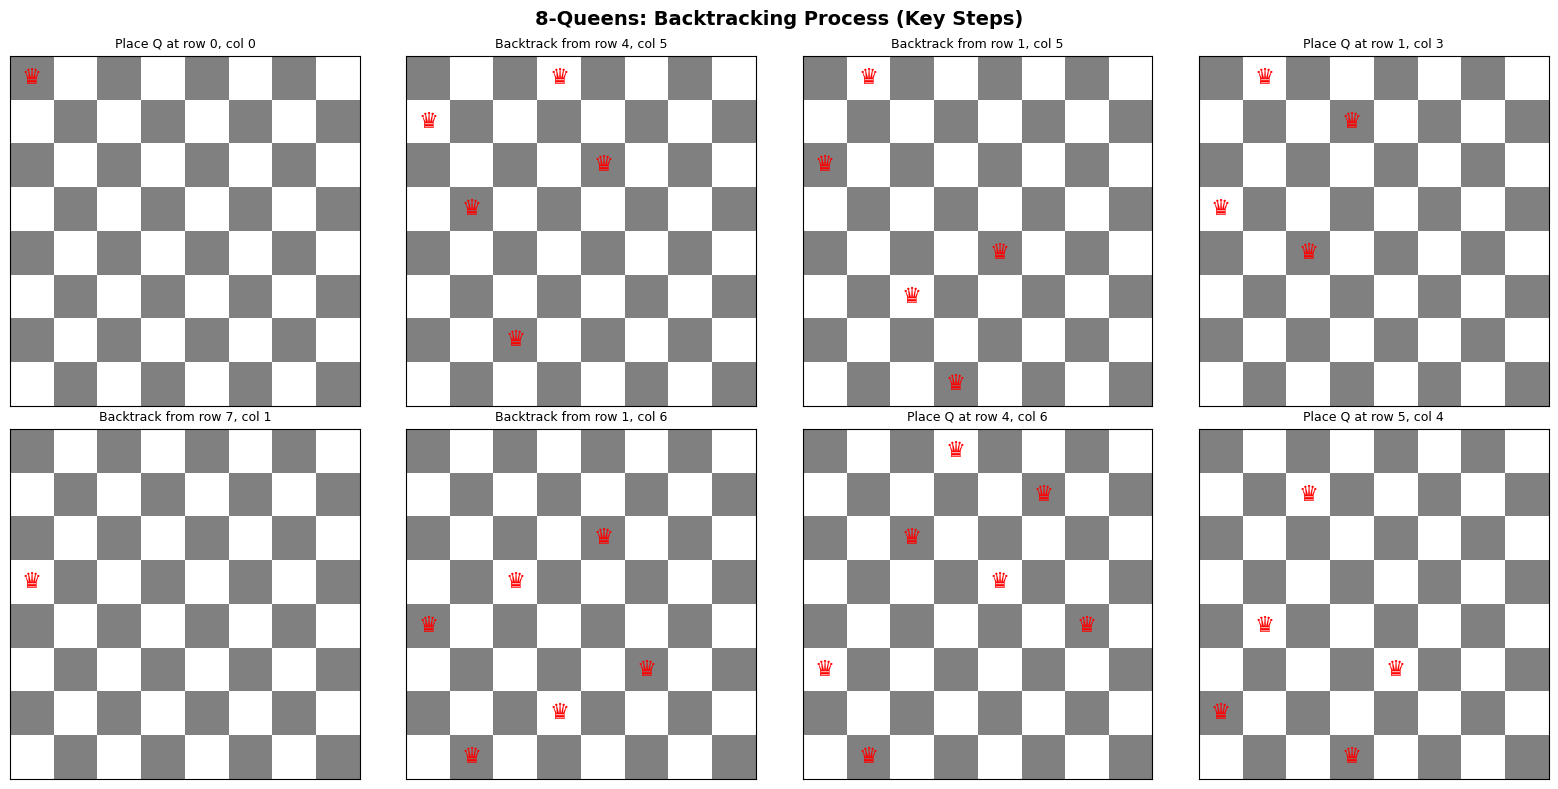

In [8]:
step_indices = list(range(0, len(frames), max(1, len(frames)//8)))
if len(frames)-1 not in step_indices:
    step_indices.append(len(frames)-1)
step_indices = step_indices[:8]  # max 8 panels

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for ax, idx in zip(axes, step_indices):
    board_img = np.indices((n, n)).sum(axis=0) % 2
    ax.imshow(board_img, cmap='gray', vmin=0, vmax=1, alpha=0.5)
    for r in range(n):
        for c in range(n):
            if frames[idx][r][c] == 1:
                ax.text(c, r, '♛', fontsize=16, ha='center', va='center', color='red')
    title_color = "green" if "Solution" in frame_info[idx] else "black"
    ax.set_title(frame_info[idx], fontsize=9, color=title_color)
    ax.set_xticks([]); ax.set_yticks([])

plt.suptitle("8-Queens: Backtracking Process (Key Steps)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("8_queens_process_grid.png", dpi=150, bbox_inches="tight")
plt.show()

In [9]:
import matplotlib.animation as animation
from IPython.display import HTML

fig, ax = plt.subplots(figsize=(5,5))

def draw_board(ax, board, title):
    ax.clear()
    board_img = np.indices((n, n)).sum(axis=0) % 2
    ax.imshow(board_img, cmap='gray', vmin=0, vmax=1, alpha=0.5)
    for r in range(n):
        for c in range(n):
            if board[r][c] == 1:
                ax.text(c, r, '♛', fontsize=24, ha='center', va='center', color='red')
    ax.set_xticks(range(n)); ax.set_yticks(range(n))
    ax.set_title(title, fontsize=10)

# Only animate first solution's path (first ~40 steps) to keep GIF short
limit = frame_info.index("Solution Found!") + 1

def update(i):
    draw_board(ax, frames[i], frame_info[i])

ani = animation.FuncAnimation(fig, update, frames=limit, interval=400, repeat=False)
ani.save("8_queens_backtracking.gif", writer="pillow", fps=2)
plt.close()

HTML(f'<img src="8_queens_backtracking.gif">')

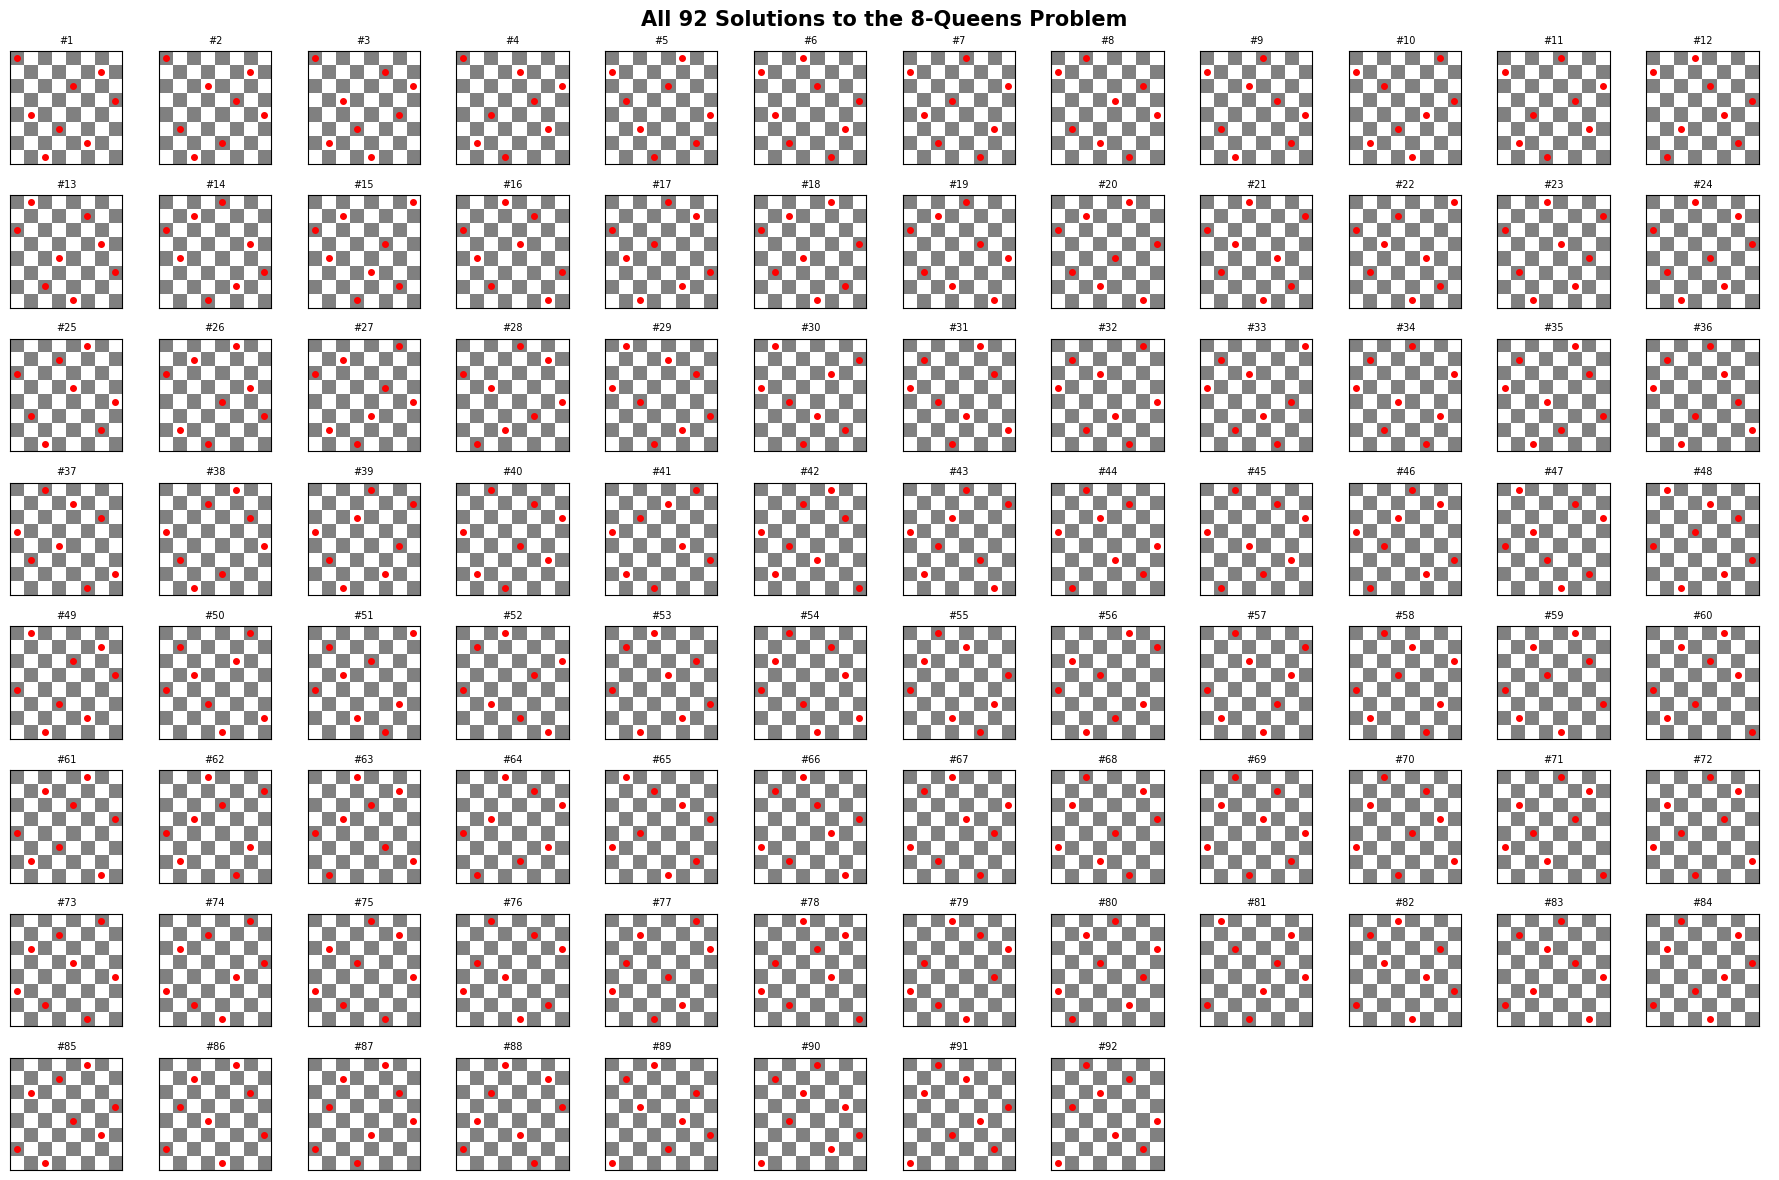

In [10]:
fig, axes = plt.subplots(8, 12, figsize=(18, 12))
axes = axes.flatten()

for i, sol in enumerate(solutions):
    ax = axes[i]
    board_img = np.indices((n, n)).sum(axis=0) % 2
    ax.imshow(board_img, cmap='gray', vmin=0, vmax=1, alpha=0.5)
    for r in range(n):
        for c in range(n):
            if sol[r][c] == 1:
                ax.plot(c, r, 'o', color='red', markersize=4)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f"#{i+1}", fontsize=7)

# hide any unused subplot boxes
for j in range(len(solutions), len(axes)):
    axes[j].axis("off")

plt.suptitle(f"All {len(solutions)} Solutions to the 8-Queens Problem", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("8_queens_all_solutions.png", dpi=150, bbox_inches="tight")
plt.show()